In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,12_ema,27_ema,MACD,Signal,MACD_hist,BB_SMA,BB_STD,Upper_Band,Lower_Band,MACD_Strategy,BB_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
191,86.470001,93.739998,86.120003,92.019997,301300,89.228036,90.344608,-1.116572,-1.071922,-0.044650,91.700000,4.336041,96.036041,87.363960,NaN,NaN,NaN,0,NaN,NaN
192,91.220001,91.220001,84.400002,85.680000,258900,89.543955,90.423850,-0.879895,-1.033159,0.153264,91.478500,4.235628,95.714129,87.242872,1.0,1.0,2.0,1,0.054932,0.054932
193,86.519997,91.050003,86.230003,89.120003,520200,89.066633,90.077088,-1.010455,-1.028584,0.018129,90.665000,3.435660,94.100660,87.229340,-1.0,0.0,-1.0,0,0.000578,0.054932
194,92.620003,93.264999,83.000000,86.550003,569700,89.625286,90.299101,-0.673815,-0.957209,0.283394,90.496500,3.237690,93.734190,87.258811,-1.0,1.0,0.0,0,0.071123,0.054932
195,86.650002,90.459999,84.790001,90.440002,276000,89.159090,89.985490,-0.826400,-0.930923,0.104523,90.074001,3.155641,93.229641,86.918360,-1.0,0.0,-1.0,0,0.002082,0.054932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1167,99.750000,100.945000,98.410004,99.169998,1163600,100.520486,107.243841,-6.723356,-8.456225,1.732869,101.653750,5.522692,107.176442,96.131057,-1.0,0.0,-1.0,0,0.153579,-0.730545
1168,97.680000,99.800003,96.410004,99.250000,1305000,100.083488,106.560710,-6.477222,-8.060424,1.583202,101.066250,5.271173,106.337423,95.795077,-1.0,0.0,-1.0,0,0.129640,-0.730545
1169,99.120003,101.849998,96.809998,99.889999,1137400,99.935259,106.029231,-6.093971,-7.667134,1.573162,100.439750,4.655738,105.095488,95.784012,-1.0,0.0,-1.0,0,0.146294,-0.730545
1170,98.110001,100.430000,97.639999,97.750000,1242600,99.654450,105.463571,-5.809121,-7.295531,1.486410,99.472750,2.397581,101.870331,97.075169,-1.0,0.0,-1.0,0,0.134613,-0.730545


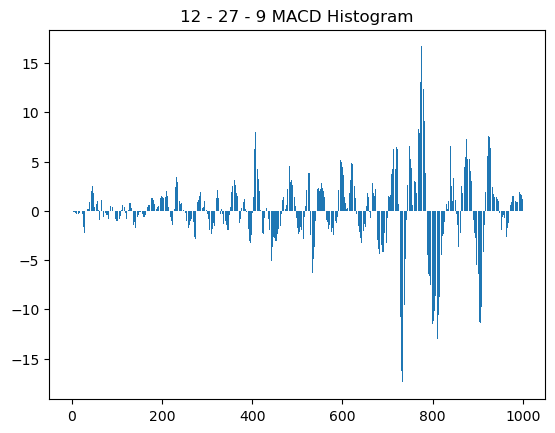

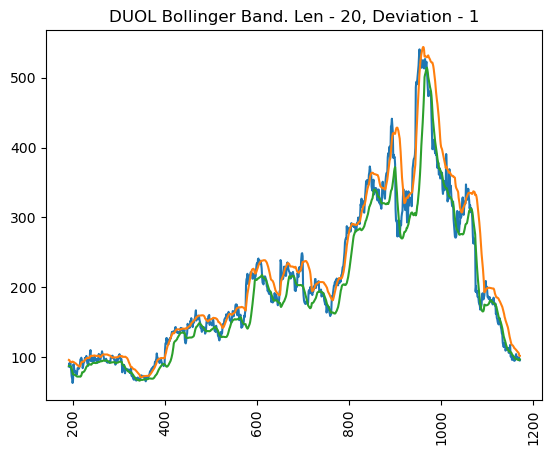

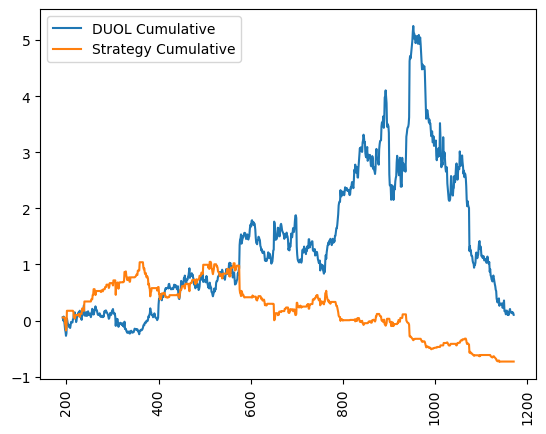

In [11]:
TICKER = 'DUOL'
BB_LEN = 20
DEVS = 1
PERIOD = '730d'
INTERVAL = '1d'
LOOKBACK = 1000
MACD_FAST = 12
MACD_SLOW = 27
MACD_SPAN = 9

def get_data(ticker=TICKER,lookback=LOOKBACK,interval=INTERVAL):


    df = yf.download(ticker,start='2000-01-01',interval=interval)
    df.columns = df.columns.get_level_values(0)

    #reset the index, so the weekends does not come in account
    df=df.reset_index(drop=True)

    return df.iloc[-lookback:, :]

def add_MACD(df, fast=MACD_FAST,slow=MACD_SLOW, span=MACD_SPAN):

    df[f'{fast}_ema'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ema'] = df['Close'].ewm(span=slow).mean()

    #macd line is the difference between the fast and slow
    df[f'MACD'] = df[f'{fast}_ema'] - df[f'{slow}_ema']

    #macd signal is a 9-period moving average of this line
    df['Signal'] = df['MACD'].ewm(span=span).mean()

    #macd histogram is almost always what is used in TA
    df['MACD_hist'] = df['MACD'] - df['Signal']

    #plot the histogram
    plt.bar(x=range(len(df)), height=df['MACD_hist'])
    plt.title(f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Histogram')

    return df

def add_MACD_strategy(df):

    df['MACD_Strategy'] = 0
    df['MACD_Strategy'] = np.where(df['MACD_hist'] < 0,1,-1)
    df['MACD_Strategy'] = df['MACD_Strategy'].shift(1)

    return df


def add_bollinger_bands(df,devs=DEVS, bb_len=BB_LEN):

    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band']  = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band']  = df['BB_SMA'] - (devs * df['BB_STD'])

    df=df.dropna()

    plt.figure()

    plt.plot(df['Close'])
    plt.plot(df['Upper_Band'])
    plt.plot(df['Lower_Band'])
    plt.xticks(rotation='vertical')

    df = df.dropna()

    plt.title(f'{TICKER} Bollinger Band. Len - {BB_LEN}, Deviation - {DEVS}')


    return df

def add_BB_strategy(df):
    df['BB_Strategy'] = 0
    df['BB_Strategy'] = np.where(df['Close'] > df['Upper_Band'], -1,
                              np.where(df['Close'] < df['Lower_Band'],1,0))
    
    df['BB_Strategy'] = df['BB_Strategy'].shift(1)
    
    return df


def add_full_strategy(df):
    
    df['Full_Strategy'] = df['MACD_Strategy'] + df['BB_Strategy']

    df['Strategy'] = np.where(df['Full_Strategy'] ==2, 1,
                     np.where(df['Full_Strategy'] == -2,-1,0 ))

    return df

def test_strategy(df):
    df['Asset_Returns'] = (1+df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = ( 1 + df['Close'].pct_change() * df['Strategy']).cumprod() - 1

    #plotting the strategy
    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.xticks(rotation='vertical')

    return df


def main():
    df = get_data()
    df = add_MACD(df)
    df = add_bollinger_bands(df)

    df = add_MACD_strategy(df)
    df = add_BB_strategy(df)

    df = add_full_strategy(df)

    df = test_strategy(df)

    return df

df = main()
df